In [1]:
#!/usr/bin/env python
import sys, glob, os
from pathlib import Path
import numpy as np
import numpy.ma as ma
from matplotlib import pyplot as plt
import cmocean.cm as cmo
import xarray as xr
import MITgcmutils as MIT
import xmitgcm as xmit
import skill_metrics as sm
import seawater

In [2]:
sys.path.append('/albedo/home/nmamnun/miniconda3/ECCOv4-py')
import ecco_v4_py as ecco

In [3]:
data_dir = '/albedo/work/projects/p_recompdaf/nmamnun/DAOUTPUTS/REF_FOR/outputs_2020'

In [5]:
def load_variable_from_mds(data_dir, prefix, var, iters='all'):
    """
    Load a specific variable from an MDS dataset.

    Parameters:
    - data_dir (str): The directory where the data files are located.
    - prefix (str): The prefix for the data files.
    - var (str): The variable name to load (e.g., 'SALT').
    - iters (str or list): Iteration numbers to load, 'all' by default.

    Returns:
    - xarray.DataArray: The specified variable from the MDS dataset.
    """
    diag = xmit.open_mdsdataset(data_dir=data_dir,
                                  grid_dir='../Grid',
                                  prefix=prefix,
                                  iters=iters,
                                  geometry='llc')
    
    return diag[var]

In [6]:
theta_2020 = load_variable_from_mds(data_dir=data_dir,
                             prefix='diag3Dm',
                             var='THETA')
salt_2020 = load_variable_from_mds(data_dir=data_dir,
                             prefix='diag3Dm',
                             var='SALT')

In [8]:
import xarray as xr
llc90_grid = xr.open_dataset('llc90_grid.nc')

In [10]:
def mask_data(data, time_dependent=False):
    # Extract the mask from the llc90_grid
    mask = llc90_grid.hFacC.values

    # Check if the mask is of the shape (50, 13, 90, 90)
    if mask.shape != (50, 13, 90, 90):
        raise ValueError("The provided grid is not an llc90 grid.")

    # Check dimensions of the data and apply the mask accordingly
    if time_dependent:
        if data.shape[1:] == (50, 13, 90, 90):
            # Extend the mask along the time dimension
            extended_mask = np.tile(mask, (data.shape[0], 1, 1, 1, 1))
            masked_data = ma.masked_where(extended_mask == 0, data)
        elif data.shape[1:] == (13, 90, 90):
            # Use only the first slice of the mask and extend along time dimension
            extended_mask = np.tile(mask[0], (data.shape[0], 1, 1, 1))
            masked_data = ma.masked_where(extended_mask == 0, data)
        else:
            raise ValueError(
                "Data dimensions with time do not match the expected shape.")
    else:
        if data.shape == (50, 13, 90, 90):
            masked_data = ma.masked_where(mask == 0, data)
        elif data.shape == (13, 90, 90):
            masked_data = ma.masked_where(mask[0] == 0, data)
        else:
            raise ValueError(
                "Data dimensions do not match the expected shape.")

    return masked_data

In [11]:
# Broadcast depth to the same shape as latitude
depth_broadcasted = xr.broadcast(llc90_grid.Z, llc90_grid.YC)[0]
depths = mask_data(depth_broadcasted)    
# Calculate pressure from depth and latitude
pressure = abs(seawater.eos80.pres(depths, llc90_grid.YC))
pressure = mask_data(pressure)

In [12]:
salt = salt_2020[0]
theta = theta_2020[0]

In [13]:
pott = mask_data(theta)
sal = mask_data(salt)
temp = seawater.eos80.temp(sal, pott, pressure)
potd = seawater.eos80.pden(sal, temp, pressure)

In [14]:
import numpy as np
import numpy.ma as ma

def compute_mld(density: ma.MaskedArray, depth: ma.MaskedArray, threshold: float = 0.03) -> ma.MaskedArray:
    """
    Compute the Mixed Layer Depth (MLD) based on a given density difference threshold.

    Parameters:
    - density: numpy.ma.MaskedArray representing potential density values. 
               Dimensions should be (time, k, face, j, i) or similar.
    - depth: numpy.ma.MaskedArray representing depth values.
             Dimensions should match that of the density.
    - threshold: Density difference threshold for MLD calculation.

    Returns:
    - mld: numpy.ma.MaskedArray representing MLD values. Dimensions will be (time, face, j, i) or similar.
    """
    
    surface_density = density[0]
    density_diff = density - surface_density
    mld_depth_indices = (density_diff > threshold).argmax(axis=0)
    mld = np.empty_like(surface_density)
    for index, depth_index in np.ndenumerate(mld_depth_indices):
        if depth_index == 0 and not density_diff[(0,) + index] > threshold:
            mld[index] = depth[0][index]
        else:
            mld[index] = depth[(depth_index,) + index]

    # Convert the result to a MaskedArray
    mld = ma.array(mld, mask=surface_density.mask)

    return abs(mld)

In [15]:
mix_layer_depth = compute_mld(potd, depths)

In [16]:
mix_layer_depths = []
for i in range(73):
    salt = salt_2020[i]
    theta = theta_2020[i]
    pott = mask_data(theta)
    sal = mask_data(salt)
    temp = seawater.eos80.temp(sal, pott, pressure)
    potd = seawater.eos80.pden(sal, temp, pressure)
    
    mld = compute_mld(potd, depths)
    
    mix_layer_depths.append(mld)
    
mix_layer_depths = np.array(mix_layer_depths)

In [17]:
mix_layer_depths = mask_data(mix_layer_depths, time_dependent=True)

In [18]:
mix_layer_depths.shape

(73, 13, 90, 90)

In [19]:
max_mld = mix_layer_depths.max(axis=0)

In [ ]:
index_of_max = mix_layer_depths.argmax(axis=0)

In [20]:
#!/usr/bin/env python
import matplotlib.pyplot as plt
from matplotlib import ticker as mticker
import numpy as np
import xarray as xr
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm
import skill_metrics as sm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pyresample as pr

def plot_llc90_global(lons, lats, data,
                      ax=None,
                      user_lat_0=45,
                      projection_type='robin',
                      plot_type='pcolor',
                      user_lon_0=0,
                      background_type='fc',
                      show_cbar_label=False,
                      show_colorbar=False,
                      colorbar_extend='neither',
                      cbar_label='',
                      bound_lat=50,
                      num_levels=20,
                      cmap='viridis',
                      dx=0.5,
                      dy=0.5,
                      show_grid_lines=True,
                      norm=None,
                      **kwargs):
    '''
    Plot MITgcm llc90 outputs.

    lons: DataArray with shape (13, 90, 90) (e.g., dataset.XC)
    lats: DataArray with shape (13, 90, 90) (e.g., dataset.YC)
    data: DataArray with shape (13, 90, 90)

    Optional arguments:
      user_lat_0: Latitude at which to center the projection (default 45)
      projection_type: Type of projection (default 'robin')
      plot_type: Type of plot (default 'pcolor')
      user_lon_0: Longitude at which to center the projection (default 0)
      background_type: Type of background (default 'fc')
      show_cbar_label: Whether to show colorbar label (default False)
      show_colorbar: Whether to show colorbar (default False)
      colorbar_extend: Colorbar extension (default 'neither')
      cbar_label: Label for colorbar (default '')
      bound_lat: Bounding latitude for polar projections (default 50)
      num_levels: Number of intervals for colorbar (default 20)
      cmap: Colormap name (default 'viridis')
      dx: Interpolate resolution for longitude (default 0.5)
      dy: Interpolate resolution for latitude (default 0.5)
      show_grid_lines: Whether to show grid lines (default True)
      norm: Colormap normalization (default None)
      **kwargs: Additional keyword arguments (e.g., cmin, cmax)

    Returns:
      f: The figure object
      ax: The map axis
      im: The image (mappable) object
    '''

    # Determine min and max value of data; override with kwargs if provided
    cmin = np.nanmin(data)
    cmax = np.nanmax(data)
    for key in kwargs:
        if key == "cmin":
            cmin = kwargs[key]
        elif key == "cmax":
            cmax = kwargs[key]
        else:
            print("unrecognized argument ", key)

    # Process lons and lats: flatten to 1D arrays if needed
    if isinstance(lons, xr.core.dataarray.DataArray):
        lons_1d = lons.values.reshape(np.product(lons.values.shape))
        lats_1d = lats.values.reshape(np.product(lats.values.shape))
    elif isinstance(lons, np.ndarray):
        lons_1d = lons.reshape(np.product(lons.shape))
        lats_1d = lats.reshape(np.product(lats.shape))
    else:
        print('lons and lats must be either a DataArray or a numpy.ndarray')
        return

    # Ensure data is a numpy array (or masked array)
    if isinstance(data, xr.core.dataarray.DataArray):
        data = data.values
    elif not (isinstance(data, np.ndarray) or isinstance(data, np.ma.core.MaskedArray)):
        print('data must be either a DataArray or ndarray type')
        return

    # Create new figure and axis if none is provided; else use the provided axis.
    if ax is None:
        f = plt.figure(figsize=(12, 9), dpi=90)
        if projection_type == 'plate':
            ax = f.add_subplot(1, 1, 1, projection=ccrs.PlateCarree(central_longitude=user_lon_0))
            ax.set_global()
        elif projection_type == 'robin':
            ax = f.add_subplot(1, 1, 1, projection=ccrs.Robinson(central_longitude=user_lon_0))
            ax.set_global()
        elif projection_type == 'ortho':
            ax = f.add_subplot(1, 1, 1, projection=ccrs.Orthographic(central_longitude=user_lon_0,
                                                                     central_latitude=user_lat_0))
            ax.set_global()
        elif projection_type == 'mollweide':
            ax = f.add_subplot(1, 1, 1, projection=ccrs.Mollweide(central_longitude=user_lon_0))
            ax.set_global()
        elif projection_type == 'stereo':
            if bound_lat > 0:
                ax = f.add_subplot(1, 1, 1, projection=ccrs.NorthPolarStereo(central_longitude=user_lon_0))
                ax.set_extent([-180.0, 180.0, bound_lat, 90.0],
                              crs=ccrs.PlateCarree())
            else:
                ax = f.add_subplot(1, 1, 1, projection=ccrs.SouthPolarStereo(central_longitude=user_lon_0))
                ax.set_extent([-180.0, 180.0, bound_lat, -90.0],
                              crs=ccrs.PlateCarree())
        else:
            raise ValueError('projection_type must be "plate", "robin", "ortho", "mollweide" or "stereo"')
    else:
        f = plt.gcf()  # use current figure if an axis is provided

    # Draw canvas and add background features.
    f.canvas.draw()
    if background_type == 'fc':
        ax.add_feature(cfeature.LAND, facecolor='peru', zorder=0)
    elif background_type == 'stock':
        ax.stock_img()
        
    # Check that the provided axis has the Cartopy method "coastlines"
    if not hasattr(ax, 'coastlines'):
        raise AttributeError("The provided axis does not have a 'coastlines' method. "
                             "Make sure to create the axis with a Cartopy projection, for example:\n"
                             "fig, axs = plt.subplots(..., subplot_kw={'projection': ccrs.Robinson(central_longitude=user_lon_0)})")
    ax.coastlines(resolution='110m')

    # Prepare interpolation/resampling using pyresample
    orig_grid = pr.geometry.SwathDefinition(lons=lons_1d, lats=lats_1d)
    lat_tmp = np.arange(-90.0, 90.0 + dy, dy)
    lon_tmp = np.arange(-180.0, 180.0 + dx, dx)
    new_grid_lon, new_grid_lat = np.meshgrid(lon_tmp, lat_tmp)
    new_grid = pr.geometry.GridDefinition(lons=new_grid_lon, lats=new_grid_lat)
    data_latlon_projection = pr.kd_tree.resample_nearest(orig_grid, data, new_grid,
                                                          radius_of_influence=100000,
                                                          fill_value=None)

    # Create the plot using either pcolor or contourf.
    if plot_type == 'pcolor':
        im = ax.pcolormesh(new_grid_lon, new_grid_lat, data_latlon_projection,
                           vmin=cmin, vmax=cmax, transform=ccrs.PlateCarree(),
                           cmap=cmap, norm=norm)
    elif plot_type == 'contourf':
        contour_levels = np.linspace(cmin, cmax, num_levels)
        im = ax.contourf(new_grid_lon, new_grid_lat, data_latlon_projection,
                         vmin=cmin, vmax=cmax, transform=ccrs.PlateCarree(),
                         cmap=cmap, norm=norm,
                         levels=contour_levels, extend=colorbar_extend)
    else:
        print('plot type must be either "pcolor" or "contourf"')
        return

    # Add grid lines if requested.
    if projection_type == 'plate' and show_grid_lines:
        ax.gridlines(draw_labels=True, color='dimgray', linestyle='--', zorder=3)
    elif show_grid_lines:
        ax.gridlines(draw_labels=False, color='dimgray', linestyle='--', zorder=3)

    # Optionally add a colorbar (if show_colorbar==True) using an extra axis.
    if show_colorbar:
        f.subplots_adjust(right=0.8)
        h = 0.6
        w = 0.025
        cbar_ax = f.add_axes([0.85, (1 - h) / 2, w, h])
        cbar = f.colorbar(im, extend=colorbar_extend, cax=cbar_ax)
        if show_cbar_label:
            cbar.set_label(cbar_label)

    plt.sca(ax)  # Set current axis to the map.
    return f, ax, im

NameError: name 'index_of_max' is not defined

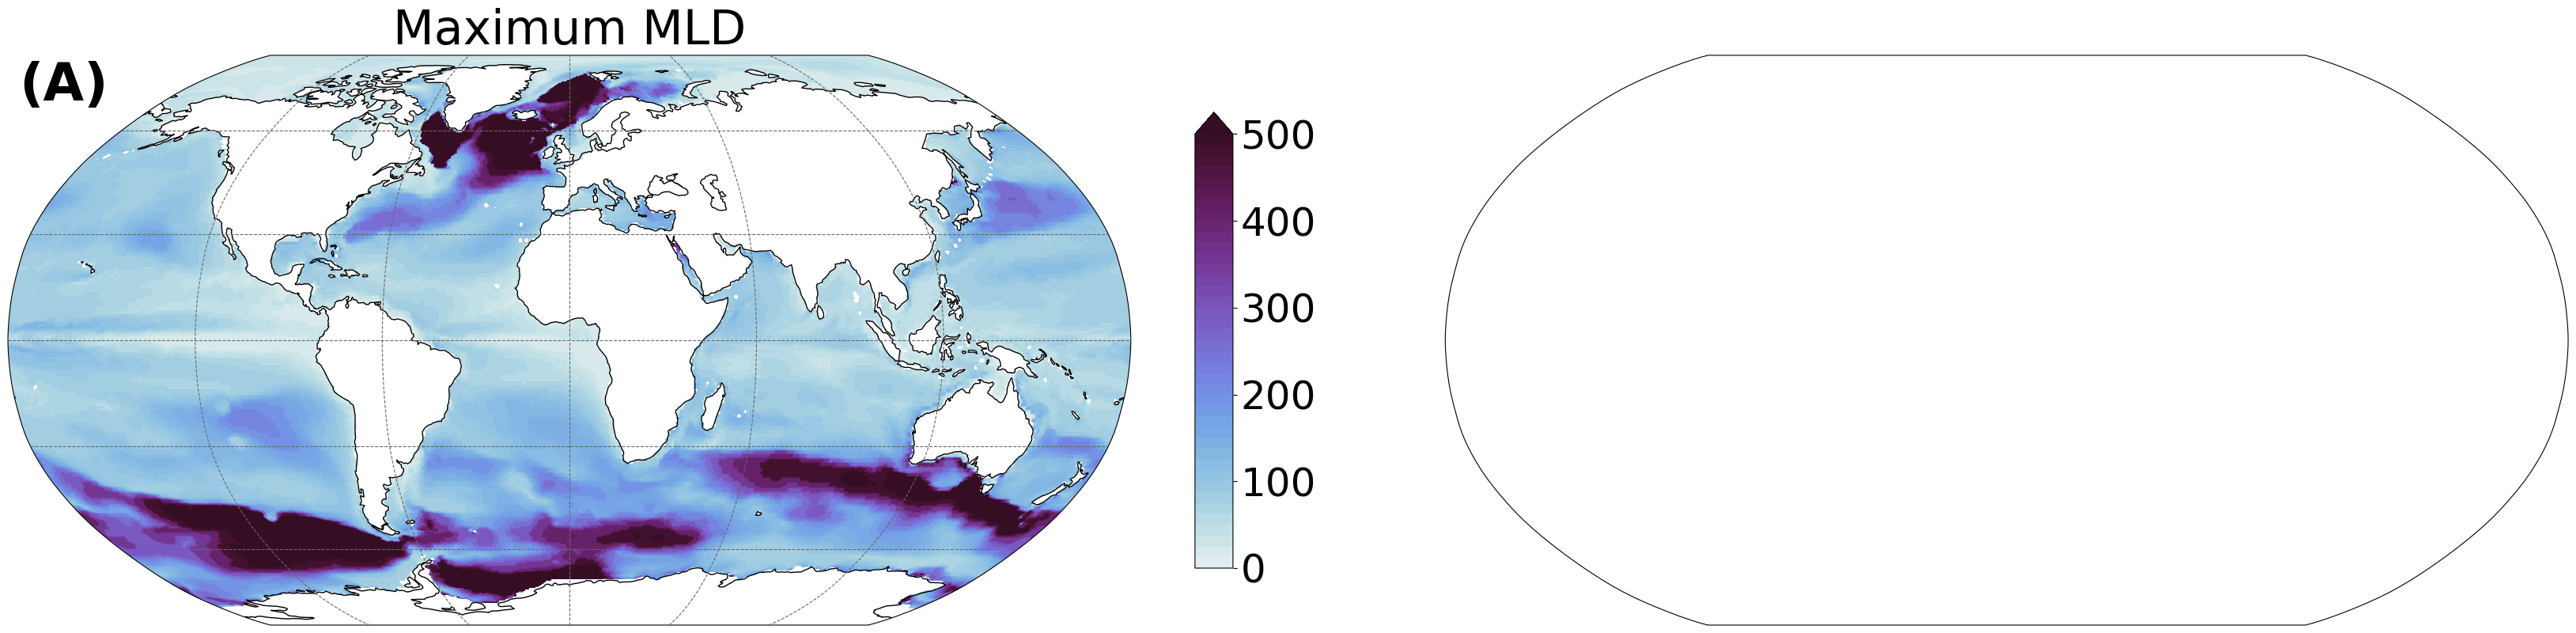

In [21]:
plt.rcParams.update({'font.size': 36})

fig, axs = plt.subplots(1, 2, figsize=(36, 8),
                        subplot_kw={'projection': ccrs.Robinson(central_longitude=0.0)},
                        constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.3, h_pad=0.1, hspace=0.0)
# ----------------------------------------------------------------------------
# PANEL (A): Maximum MLD
cmin = 0.0
cmax = 500.0
num_levels = 41
cbar_ticks_A = [0., 100., 200., 300., 400., 500.]

# Plot the maximum MLD using plot_llc90_global.
# It is assumed this function plots into the provided axis and returns (fig, ax, mappable).
ax = axs[0]
_, _, imA = plot_llc90_global(
    llc90_grid.XC, llc90_grid.YC, 
    max_mld,
    ax=ax,
    show_colorbar=False,       # Disable internal colorbar creation
    colorbar_extend='max',
    cmap=cmo.dense,
    num_levels=num_levels,
    cmin=cmin,
    cmax=cmax,
    plot_type='contourf',
    show_grid_lines=True,
    background_type=None,
    user_lon_0=0.0,
    projection_type='robin',
)

# Add a colorbar for Panel (A)
cbarA = fig.colorbar(imA, ax=ax, ticks=cbar_ticks_A, shrink=0.8, pad=0.05, aspect=12)
# (Optionally set ticklabels if desired; for now we use the default numeric labels)
ax.set_title('Maximum MLD', pad=10)
ax.text(0.01, 0.99, '(A)', transform=ax.transAxes, 
        verticalalignment='top', horizontalalignment='left', 
        fontsize=48, fontweight='bold')

# ----------------------------------------------------------------------------
# PANEL (B): Month of Max. MLD
cmin = 0.0
cmax = 73.0
num_levels = 13
cbar_ticks_B = [0., 12., 24., 36., 47., 60., 73.]

ax = axs[1]
_, _, imB = plot_llc90_global(
    llc90_grid.XC, llc90_grid.YC, 
    mask_data(index_of_max),
    ax=ax,
    show_colorbar=False,       # Disable the internal colorbar creation
    colorbar_extend=None,
    cmap=cmo.balance,
    num_levels=num_levels,
    cmin=cmin,
    cmax=cmax,
    plot_type='contourf',
    show_grid_lines=True,
    background_type=None,
    user_lon_0=0.0,
    projection_type='robin',
)

# Add a colorbar for Panel (B) and set custom tick labels.
cbarB = fig.colorbar(imB, ax=ax, ticks=cbar_ticks_B, shrink=0.8, pad=0.05, aspect=12)
cbarB.set_ticklabels(['00', '02', '04', '06', '08', '10', '12'])
ax.set_title('Month of Max. MLD', pad=10)
ax.text(0.01, 0.99, '(B)', transform=ax.transAxes, 
        verticalalignment='top', horizontalalignment='left', 
        fontsize=48, fontweight='bold')

# plt.savefig("Fig_mld.jpg", bbox_inches='tight', dpi=300) 

plt.show()